In [19]:
# ===============================
# Import Libraries
# ===============================
import os
os.environ["OMP_NUM_THREADS"] = "2"
import warnings
warnings.simplefilter("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [11]:
df = pd.read_csv("Data/raw_wholesale_customers.csv")

print("Dataset Shape:")
# print(df.shape)

print()

# print(df.head())

Dataset Shape:



In [3]:
# print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None


In [4]:
 # Select Features
features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = df[features].copy()

# print(X.head())

   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185


<!-- Apply IQR Capping -->
for col in features:

    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X[col] = X[col].clip(lower, upper)

print("IQR Capping Completed")
print(df.head())

In [6]:
for col in features:

    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X[col] = X[col].clip(lower, upper)
    print(X.head())
    

print("IQR Capping Completed")

     Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669.0  9656.0   7561.0   214.0            2674.0     1338.00
1   7057.0  9810.0   9568.0  1762.0            3293.0     1776.00
2   6353.0  8808.0   7684.0  2405.0            3516.0     3938.25
3  13265.0  1196.0   4221.0  6404.0             507.0     1788.00
4  22615.0  5410.0   7198.0  3915.0            1777.0     3938.25
     Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669.0  9656.0   7561.0   214.0            2674.0     1338.00
1   7057.0  9810.0   9568.0  1762.0            3293.0     1776.00
2   6353.0  8808.0   7684.0  2405.0            3516.0     3938.25
3  13265.0  1196.0   4221.0  6404.0             507.0     1788.00
4  22615.0  5410.0   7198.0  3915.0            1777.0     3938.25
     Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669.0  9656.0   7561.0   214.0            2674.0     1338.00
1   7057.0  9810.0   9568.0  1762.0            3293.0     1776.00
2   6353.0

In [7]:
print(X.describe())

              Fresh          Milk      Grocery       Frozen  Detergents_Paper  \
count    440.000000    440.000000    440.00000   440.000000        440.000000   
mean   11357.568182   5048.592045   7236.37500  2507.085795       2392.616477   
std    10211.542235   4386.377073   6596.53308  2408.297738       2940.794090   
min        3.000000     55.000000      3.00000    25.000000          3.000000   
25%     3127.750000   1533.000000   2153.00000   742.250000        256.750000   
50%     8504.000000   3627.000000   4755.50000  1526.000000        816.500000   
75%    16933.750000   7190.250000  10655.75000  3554.250000       3922.000000   
max    37642.750000  15676.125000  23409.87500  7772.250000       9419.875000   

        Delicassen  
count   440.000000  
mean   1266.715341  
std    1083.069792  
min       3.000000  
25%     408.250000  
50%     965.500000  
75%    1820.250000  
max    3938.250000  


In [8]:
# Scale Features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed")

print(X_scaled[:5])

Scaling Completed
[[ 0.12857261  1.05158597  0.04926747 -0.95324427  0.09579175  0.06589216]
 [-0.42162716  1.08673463  0.35386453 -0.30973493  0.30651872  0.47075856]
 [-0.49064723  0.85804007  0.06793486 -0.04243744  0.38243489  2.46943983]
 [ 0.18700437 -0.87930823 -0.45763545  1.61996169 -0.64192284  0.48185079]
 [ 1.10367719  0.08248706 -0.00582407  0.58527516 -0.20957511  2.46943983]]


In [24]:
# Elbow Method
sse = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        algorithm="lloyd"
    )

    model.fit(X_scaled)
    sse.append(model.inertia_)

print("SSE Values")

for i, value in enumerate(sse, 1):
    print(f"k={i}: {value:.2f}")

SSE Values
k=1: 2640.00
k=2: 1728.03
k=3: 1361.43
k=4: 1179.94
k=5: 1043.80
k=6: 932.29
k=7: 838.69
k=8: 773.50
k=9: 726.79
k=10: 694.18


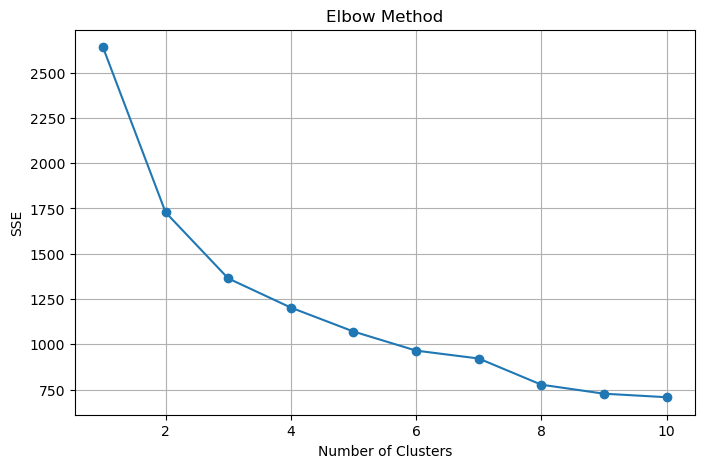

In [14]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),sse,marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("SSE")

plt.grid(True)

plt.show()

In [15]:
# Train K-Means
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init="auto"
)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  KMeans_Cluster  
0        1338               0  
1        1776               0  
2        7844               0  
3        1788               3  
4        5185               3  


In [16]:
# ==================================
# Cluster Centers (Original Units)
# ==================================

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

cluster_centers = pd.DataFrame(
    centers_original,
    columns=features
)

print("Cluster Centers (Original Spend Units)")
print(cluster_centers.round(2))

Cluster Centers (Original Spend Units)
      Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
0   9202.67   6833.30   9104.12  1326.16           3280.12     1871.76
1   8376.23   2150.65   3160.63  1646.33            779.25      674.02
2  17461.54  13805.60  17524.12  4120.57           5460.56     3583.64
3  22346.70   3409.14   3969.33  5819.60            583.07     1566.95
4   4916.98  10768.85  18350.13  1212.37           7780.02      981.37


In [17]:
df.to_csv("segmented_wholesale_customers.csv", index=False)

print("Saved clustered dataset → segmented_wholesale_customers.csv")

Saved clustered dataset → segmented_wholesale_customers.csv


In [18]:
print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  KMeans_Cluster  
0        1338               0  
1        1776               0  
2        7844               0  
3        1788               3  
4        5185               3  
